# Feature Engineering

Ovaj notebook služi za anlizu i izvlačenja feature-a iz partija za svakog igrača.  
Cilj je istražiti koji su feature-i pogodni za usporedbu te koje najbolje opisiju svakog igrača.

--- 

## 1️. Uvoz biblioteka i podešavanje putanje

Prvo podešavamo putanju kako bi mogli uvseti svoje funkcije. Zatim uvozimo potrebne pakete za parsiranje PGN datoteka i vizualizaciju podataka te iz direktorija src uvozimo dvije funkcije koje će nam pomoći u analizi parse_games i extract_features.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
import chess.pgn
import matplotlib.pyplot as plt
import numpy as np
from parser import parse_games
from features import extract_features

---

# 2. Parsiranje     
Parisiramo kako pi dobili odigrane mečeva po igraču, otvaranja i broj odigranih mečeva te filtriramo po broju minimalnih odigranih mečeva koje igrač mora odigrati.

In [3]:
player_games, opening_count, num_of_games = parse_games("../data/raw/lichess_db_standard_rated_2013-01.pgn", 20)

In [4]:
print(player_games["mamalak"])

[{'color': 'Black', 'result': 'Lose', 'opening': 'French Defense: Normal Variation', 'game': [Move.from_uci('e2e4'), Move.from_uci('e7e6'), Move.from_uci('d2d4'), Move.from_uci('b7b6'), Move.from_uci('a2a3'), Move.from_uci('c8b7'), Move.from_uci('b1c3'), Move.from_uci('g8h6'), Move.from_uci('c1h6'), Move.from_uci('g7h6'), Move.from_uci('f1e2'), Move.from_uci('d8g5'), Move.from_uci('e2g4'), Move.from_uci('h6h5'), Move.from_uci('g1f3'), Move.from_uci('g5g6'), Move.from_uci('f3h4'), Move.from_uci('g6g5'), Move.from_uci('g4h5'), Move.from_uci('g5h4'), Move.from_uci('d1f3'), Move.from_uci('e8d8'), Move.from_uci('f3f7'), Move.from_uci('b8c6'), Move.from_uci('f7e8')]}, {'color': 'Black', 'result': 'Lose', 'opening': 'French Defense: Normal Variation', 'game': [Move.from_uci('e2e4'), Move.from_uci('e7e6'), Move.from_uci('d2d4'), Move.from_uci('b7b6'), Move.from_uci('d4d5'), Move.from_uci('f8b4'), Move.from_uci('c2c3'), Move.from_uci('b4c5'), Move.from_uci('b2b4'), Move.from_uci('c5d6'), Move.f

---

# 3. Izvlačenje feature-a iz partija        
Korisitmo partije za svakog igrača te zatim za svakog igrača računamo njegov feature vektor


In [5]:
players_feat_vectors = []
for games in player_games.values():
    feat_vector = extract_features(games, num_of_moves=10)
    players_feat_vectors.append(feat_vector)
players_feat_vectors = np.array(players_feat_vectors)


---

## 4. Ispisi izračunatih feature-a 

### 1. Center pressure score       
Koliko poteza vrši pritisak na centralna polja (e4, d4, e5, d5).        
Mjeri se samo u otvaranju

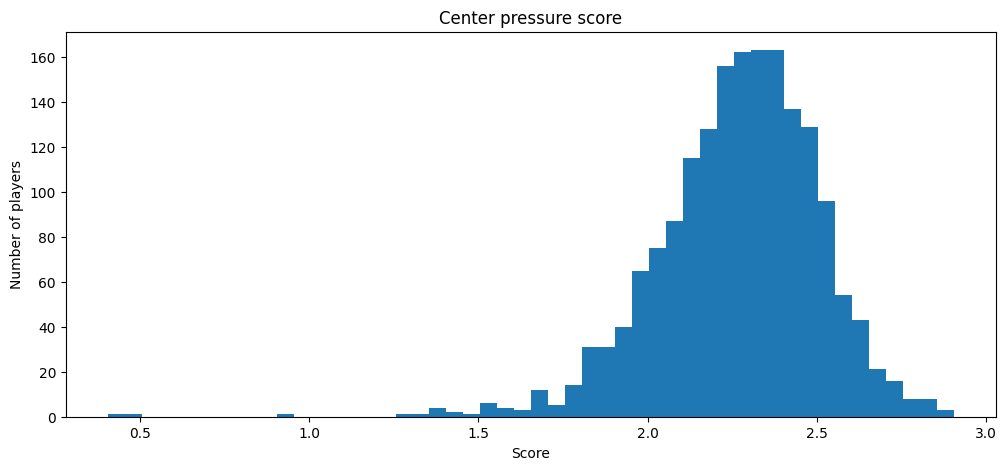

In [37]:
center_pressure = players_feat_vectors[:, 0]
plt.figure(figsize=(12,5))
plt.hist(center_pressure,bins=50)
plt.title("Center pressure score")
plt.xlabel("Score")
plt.ylabel("Number of players")
plt.show()


---
### 2. Sacrifice count i 3. Sacrifice score
Broj poteza kojim se namjerno žrvtuje materijal i vrijednost žrtvovanog materijala

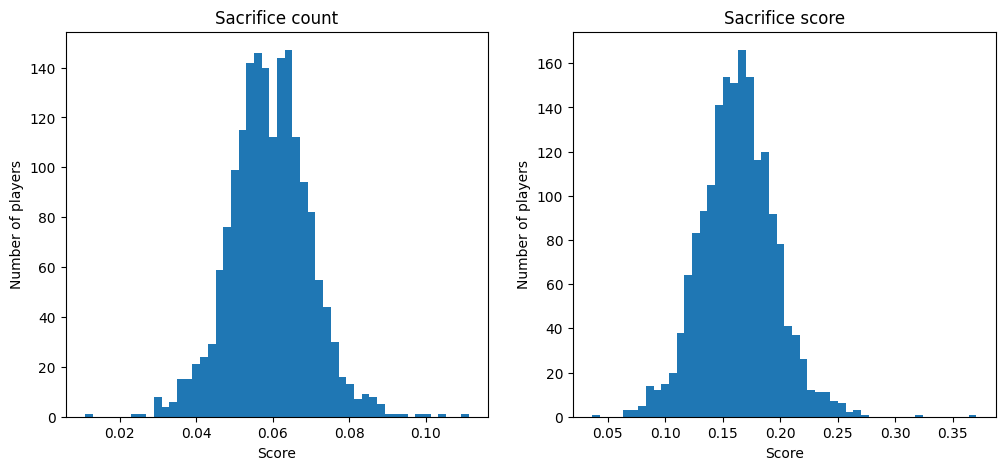

In [33]:
sacrifice_count = players_feat_vectors[:,1]
sacrifice_score = players_feat_vectors[:,2]
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].hist(sacrifice_count, bins=50)
ax[0].set_ylabel("Number of players")
ax[0].set_xlabel("Score")
ax[0].set_title("Sacrifice count")
ax[1].hist(sacrifice_score, bins=50)
ax[1].set_ylabel("Number of players")
ax[1].set_title("Sacrifice score")
ax[1].set_xlabel("Score")

plt.show()


---
### 4. Exchange count i 5. Early captures       

Ukupan broj razmjena figura.        
Broj uzimanja figura u otvaranju (num_of_moves)


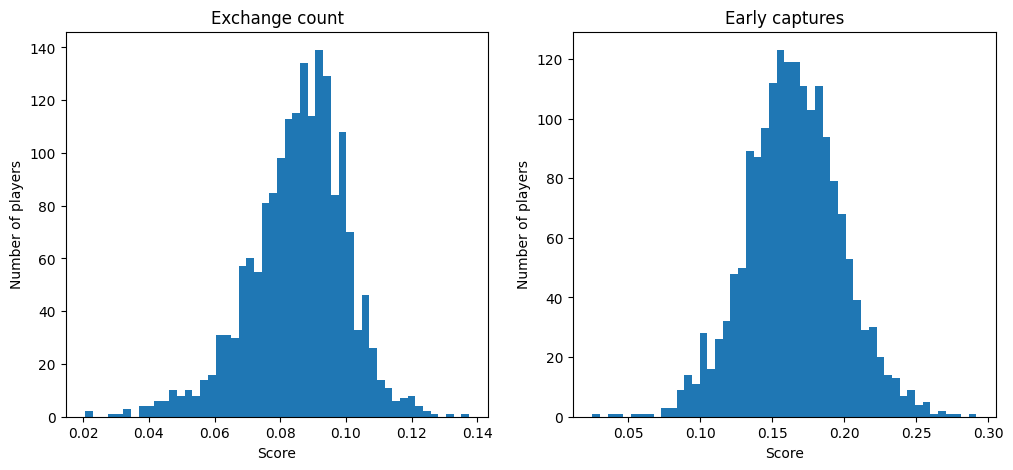

In [32]:
exchange_count = players_feat_vectors[:,3]
early_captures = players_feat_vectors[:,4]
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].hist(exchange_count, bins=50)
ax[0].set_ylabel("Number of players")
ax[0].set_xlabel("Score")
ax[0].set_title("Exchange count")
ax[1].hist(early_captures, bins=50)
ax[1].set_ylabel("Number of players")
ax[1].set_title("Early captures")
ax[1].set_xlabel("Score")

plt.show()

---
### 6. Development score i 7. Repeated moves

Mjeri koliko brzo i efikasno razvijaš figure.       
Broj puta kada ista figura igra više puta u openingu umjesto razvoja drugih figura.

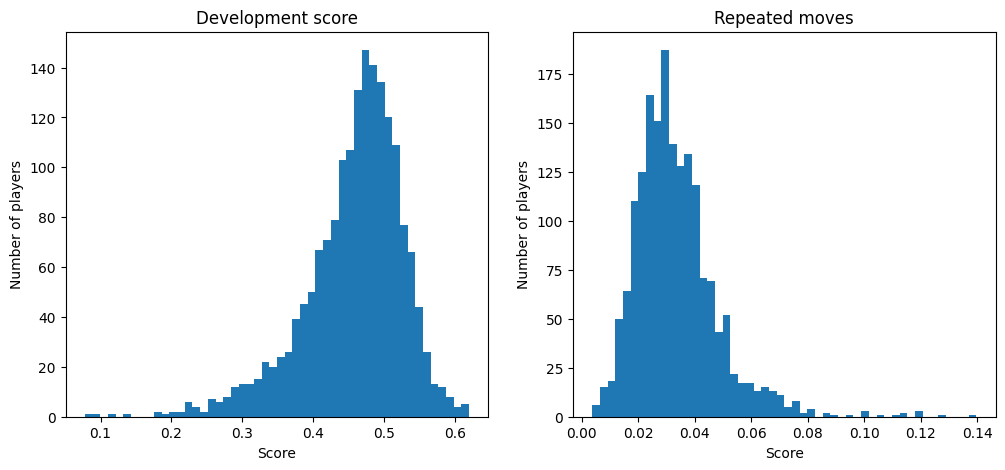

In [42]:
development_score = players_feat_vectors[:,5]
repeated_moves = players_feat_vectors[:,6]
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].hist(development_score, bins=50)
ax[0].set_ylabel("Number of players")
ax[0].set_xlabel("Score")
ax[0].set_title("Development score")
ax[1].hist(repeated_moves, bins=50)
ax[1].set_ylabel("Number of players")
ax[1].set_title("Repeated moves")
ax[1].set_xlabel("Score")

plt.show()

---
### 8. Castiling preformed i 9. Castling delay

Označava da li je igrač napravio rokadu u openingu (0/1 ili broj poteza do rokade).     
Broj poteza prije nego što je rokada napravljena (MAX_MOVES = 40).

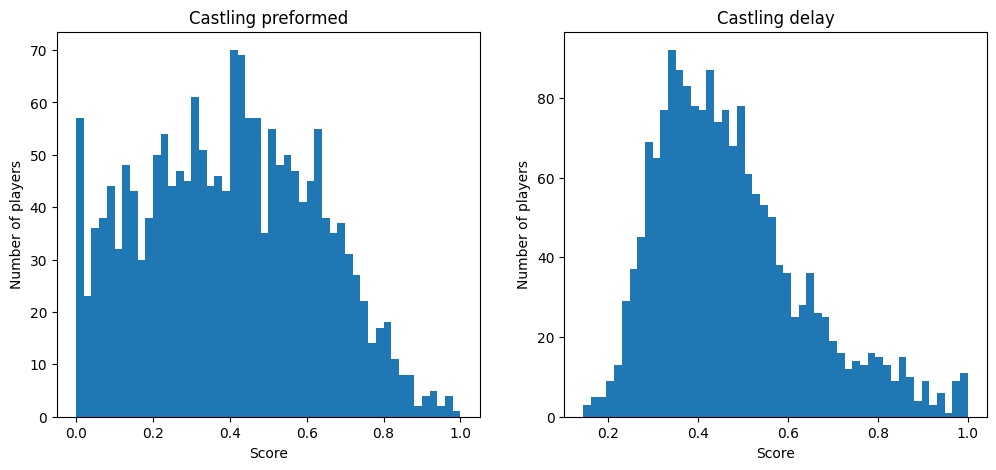

In [44]:
castling_preformed = players_feat_vectors[:,7]
castling_delay = players_feat_vectors[:,8]
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].hist(castling_preformed, bins=50)
ax[0].set_ylabel("Number of players")
ax[0].set_xlabel("Score")
ax[0].set_title("Castling preformed")
ax[1].hist(castling_delay, bins=50)
ax[1].set_ylabel("Number of players")
ax[1].set_title("Castling delay")
ax[1].set_xlabel("Score")

plt.show()

---
### 10. Attack moves i 11. Checks given

Broj poteza koji direktno napadaju protivničke figure.      
Ukupan broj šahova koje je igrač dao.


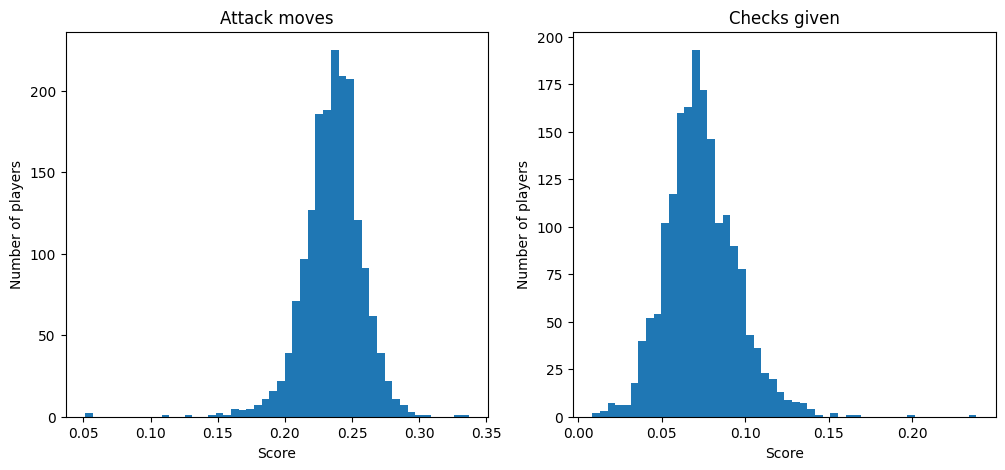

In [45]:
attack_moves = players_feat_vectors[:,9]
checks_given = players_feat_vectors[:,10]
fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].hist(attack_moves, bins=50)
ax[0].set_ylabel("Number of players")
ax[0].set_xlabel("Score")
ax[0].set_title("Attack moves")
ax[1].hist(checks_given, bins=50)
ax[1].set_ylabel("Number of players")
ax[1].set_title("Checks given")
ax[1].set_xlabel("Score")

plt.show()

---
### 12. Pawn moves ratio

Omjer poteza pijunima u odnosu na sve poteze.

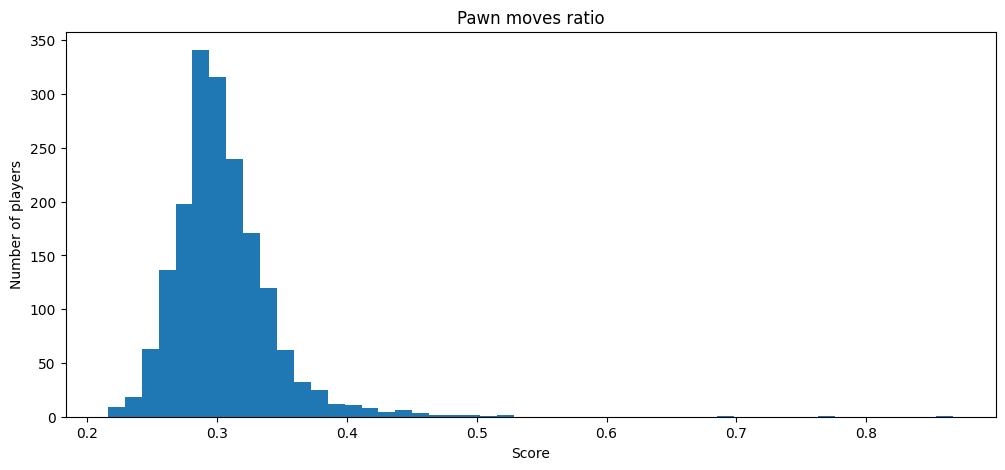

In [46]:
pawn_moves = players_feat_vectors[:, 11]
plt.figure(figsize=(12,5))
plt.hist(pawn_moves,bins=50)
plt.title("Pawn moves ratio")
plt.xlabel("Score")
plt.ylabel("Number of players")
plt.show()